In [38]:
import pandas as pd
import numpy as np
df = pd.read_csv('/content/Superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [39]:
print("\nMissing values per column:")
display(df.isnull().sum())


Missing values per column:


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [40]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print("Data types after date conversion:")
print(df[['Order Date', 'Ship Date']].dtypes)

Data types after date conversion:
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [41]:
duplicate_count = df.duplicated().sum() # Remove duplicates
if duplicate_count > 0:
    print(f"Removing {duplicate_count} duplicate rows.")
    df = df.drop_duplicates()
else:
    print("No duplicate rows found.")

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day
df['Month_Year'] = df['Order Date'].dt.to_period('M')
display(df[['Order Date', 'Year', 'Month', 'Day']].head())

No duplicate rows found.


,Order Date,Year,Month,Day
0,2016-11-08,2016,11,8
1,2016-11-08,2016,11,8
2,2016-06-12,2016,6,12
3,2015-10-11,2015,10,11
4,2015-10-11,2015,10,11


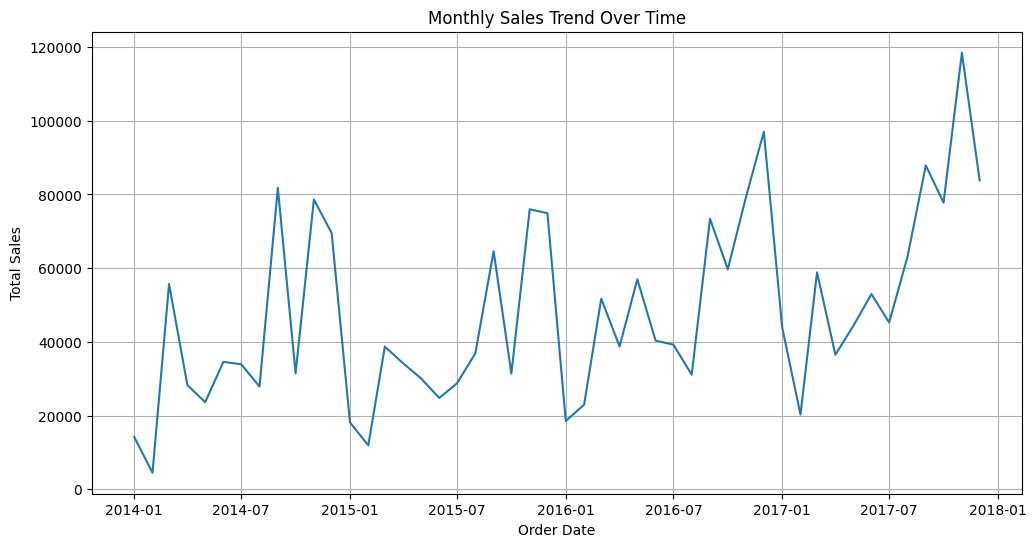

In [42]:
#Sales per month
import matplotlib.pyplot as plt
import seaborn as sns

monthly_sales = df.groupby('Month_Year')['Sales'].sum().reset_index()
monthly_sales['Month_Year'] = monthly_sales['Month_Year'].dt.to_timestamp()

plt.figure(figsize=(12, 6))
sns.lineplot(x='Month_Year', y='Sales', data=monthly_sales)
plt.title('Monthly Sales Trend Over Time')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

Highest Sales Month: 2017-11 with $118,447.82
Lowest Sales Month: 2014-02 with $4,519.89


/tmp/ipykernel_2611/3054570083.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='Sales', data=seasonal_sales, palette='viridis')


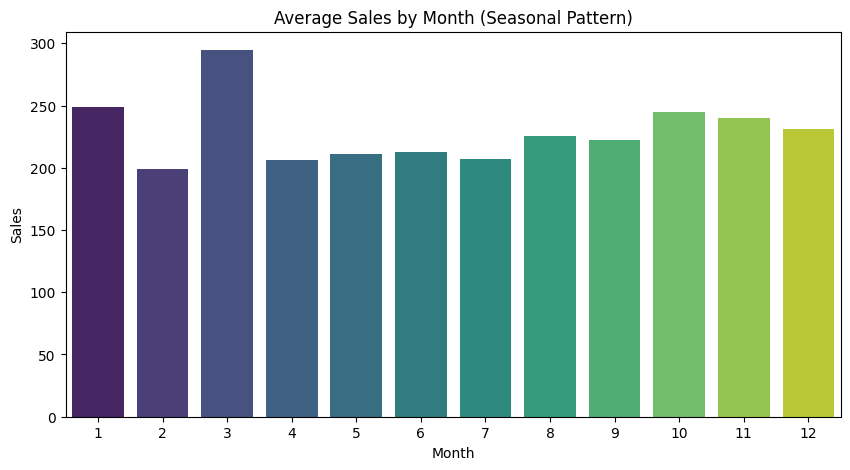

In [43]:
max_sales = monthly_sales.loc[monthly_sales['Sales'].idxmax()]
min_sales = monthly_sales.loc[monthly_sales['Sales'].idxmin()]

print(f"Highest Sales Month: {max_sales['Month_Year'].strftime('%Y-%m')} with ${max_sales['Sales']:,.2f}")
print(f"Lowest Sales Month: {min_sales['Month_Year'].strftime('%Y-%m')} with ${min_sales['Sales']:,.2f}")

seasonal_sales = df.groupby('Month')['Sales'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(x='Month', y='Sales', data=seasonal_sales, palette='viridis')
plt.title('Average Sales by Month (Seasonal Pattern)')
plt.show()

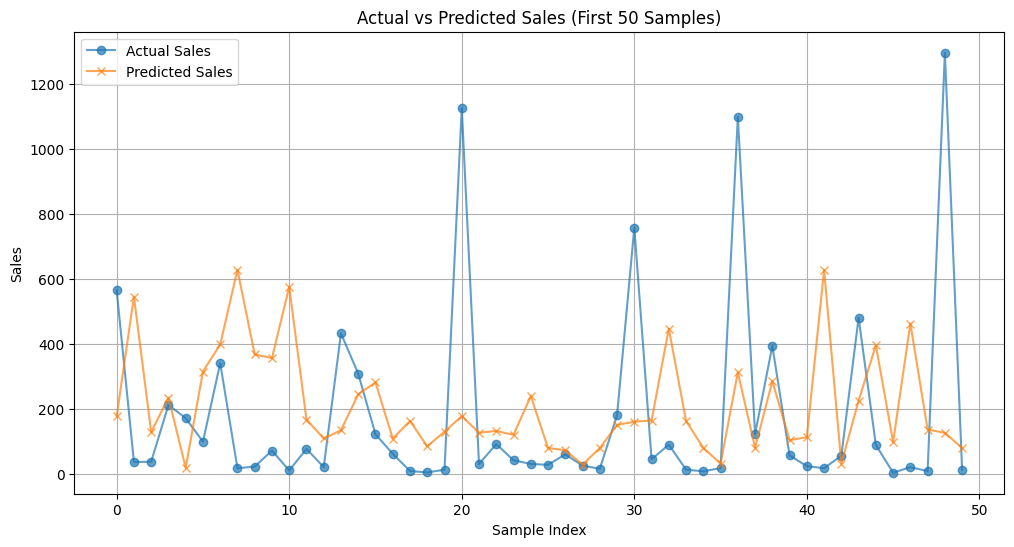

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:50], label='Actual Sales', marker='o', alpha=0.7)
plt.plot(y_pred[:50], label='Predicted Sales', marker='x', alpha=0.7)
plt.title('Actual vs Predicted Sales (First 50 Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()